# 01 · EDA — Global Forest Watch (GFW)
Análisis exploratorio del dataset raw de alertas de deforestación.  
**Objetivo:** entender la estructura, calidad y distribución de los datos *antes* de transformar.  
Los hallazgos de esta sección guían las decisiones de transformación en `05_etl_pipeline.ipynb`.

Fuente: `data/csv/bol_alerts_*.csv` y `col_alerts_*.csv` (descargados por `scripts/batch_download.py`)

## 0. Setup
Importa librerías, define rutas de datos y carga los CSVs de alertas GFW para Bolivia y Colombia. Si los archivos no están localmente, los descarga desde el proxy S3.

In [84]:
# ── Adquisición de datos: lectura local o descarga desde S3 vía Proxy ──
import os, requests
from pathlib import Path
try:
    from dotenv import load_dotenv
    load_dotenv(Path("..") / ".env")
except ImportError:
    pass

PROXY_URL = os.getenv("DATA_PROXY_URL", "https://docs.jhoanhurtado.com").rstrip("/")

def ensure_csv(proxy_rel_path: str, local_path: str):
    """Si el archivo local no existe, lo descarga desde S3 a través del proxy inverso."""
    local = Path(local_path)
    if local.exists() and local.stat().st_size > 0:
        print(f"✅ Archivo local listo: {local} ({local.stat().st_size/1e6:.1f} MB)")
        return
    
    url = f"{PROXY_URL}/{proxy_rel_path}"
    print(f"⬇ No encontrado localmente. Descargando desde S3 ({url})...")
    try:
        local.parent.mkdir(parents=True, exist_ok=True)
        with requests.get(url, stream=True, timeout=120) as r:
            r.raise_for_status()
            with open(local, "wb") as f:
                for chunk in r.iter_content(chunk_size=1048576):
                    f.write(chunk)
        print(f"✅ Descarga exitosa: {local} ({local.stat().st_size/1e6:.1f} MB)")
    except Exception as e:
        print(f"⚠️ Error al descargar desde S3 proxy ({url}): {e}")
        if not local.exists():
            raise FileNotFoundError(f"❌ No se encontró el dataset en {local} ni se pudo descargar desde {url}.")

ensure_csv("deforestacion-alert-etl/gfw/bol_alerts_2022-01-01_2026-07-31.csv", "../data/csv/bol_alerts_2022-01-01_2026-07-31.csv")
ensure_csv("deforestacion-alert-etl/gfw/col_alerts_2022-01-01_2026-07-31.csv", "../data/csv/col_alerts_2022-01-01_2026-07-31.csv")


✅ Archivo local listo: ../data/csv/bol_alerts_2022-01-01_2026-07-31.csv (48.2 MB)
✅ Archivo local listo: ../data/csv/col_alerts_2022-01-01_2026-07-31.csv (51.7 MB)


In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from glob import glob

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_CSV = Path('../data/csv')
RES      = Path('../data/results'); RES.mkdir(parents=True, exist_ok=True)

COUNTRIES = {'BOL': 'Bolivia', 'COL': 'Colombia'}

def find_csv(code):
    files = sorted(DATA_CSV.glob(f'{code.lower()}_alerts_*.csv'))
    if not files:
        raise FileNotFoundError(f'No CSV encontrado para {code} en {DATA_CSV}')
    return files[-1]   # el más reciente

print('CSVs disponibles:')
for code in COUNTRIES:
    try:
        p = find_csv(code)
        print(f'  {code}: {p.name}  ({p.stat().st_size/1e6:.1f} MB)')
    except FileNotFoundError as e:
        print(f'  ⚠️  {e}')

CSVs disponibles:
  BOL: bol_alerts_2022-01-01_2026-07-31.csv  (48.2 MB)
  COL: col_alerts_2022-01-01_2026-07-31.csv  (51.7 MB)


## 1. Carga y estructura
Lee los CSVs raw de GFW para cada país y muestra el número de filas, columnas y una muestra de los datos para entender el esquema original de la API.

In [86]:
frames = {}
for code, name in COUNTRIES.items():
    df = pd.read_csv(find_csv(code), parse_dates=['gfw_integrated_alerts__date'])
    frames[code] = df
    print(f'{name} ({code}): {len(df):>10,} filas | {df.shape[1]} columnas')

print(f'\nTotal: {sum(len(f) for f in frames.values()):,} filas')
print('\nColumnas:')
for col in frames['BOL'].columns:
    print(f'  {col}: {frames["BOL"][col].dtype}')

Bolivia (BOL):    724,000 filas | 12 columnas
Colombia (COL):    799,990 filas | 12 columnas

Total: 1,523,990 filas

Columnas:
  latitude: float64
  longitude: float64
  gfw_integrated_alerts__date: datetime64[us]
  gfw_integrated_alerts__confidence: str
  gfw_integrated_alerts__intensity: int64
  umd_tree_cover_density_2000__percent: int64
  is__umd_regional_primary_forest_2001: int64
  wdpa_protected_areas__iucn_cat: int64
  esa_land_cover_2015__class: str
  wri_google_tree_cover_loss_drivers__category: int64
  gadm_administrative_boundaries__adm1: int64
  is__umd_soy_planted_area_buffered_10km: int64


In [87]:
# Muestra de filas
frames['BOL'].head(3)

,latitude,longitude,gfw_integrated_alerts__date,gfw_integrated_alerts__confidence,gfw_integrated_alerts__intensity,umd_tree_cover_density_2000__percent,is__umd_regional_primary_forest_2001,wdpa_protected_areas__iucn_cat,esa_land_cover_2015__class,wri_google_tree_cover_loss_drivers__category,gadm_administrative_boundaries__adm1,is__umd_soy_planted_area_buffered_10km
0,-13.03755,-68.11865,2022-01-02,highest,55,99,1,0,Agriculture,5,4,0
1,-13.03795,-68.11835,2022-01-02,highest,55,99,1,0,Agriculture,5,4,0
2,-13.03825,-68.11765,2022-01-02,highest,55,99,1,0,Agriculture,5,4,0


## 2. Calidad de datos
Revisa nulos por columna, duplicados y rango de fechas. Identifica columnas problemáticas que requieren tratamiento antes de la transformación.

> **Decisiones de transformación que se derivan de esta sección:**
> - Columnas con nulos → estrategia de imputación o exclusión
> - Duplicados → deduplicar antes de migrar
> - Valores anómalos en `adm1_code` → mapear a 'Desconocido'
> - Columna `confidence` → derivar flag binario `is_high_confidence`

In [88]:
for code, df in frames.items():
    nulls    = df.isnull().sum()
    null_pct = (nulls / len(df) * 100).round(2)
    dups     = df.duplicated().sum()
    date_col = 'gfw_integrated_alerts__date'

    print(f'\n── {COUNTRIES[code]} ({code}) ──')
    print(f'  Filas: {len(df):,} | Columnas: {df.shape[1]}')
    print(f'  Duplicados: {dups:,}')
    print(f'  Rango fechas: {df[date_col].min().date()} → {df[date_col].max().date()}')
    print('  Nulos por columna:')
    nulos = pd.DataFrame({'nulls': nulls, 'null_%': null_pct})
    nulos_presentes = nulos[nulos['nulls'] > 0]
    if nulos_presentes.empty:
        print('    Sin valores nulos')
    else:
        print(nulos_presentes.to_string())


── Bolivia (BOL) ──
  Filas: 724,000 | Columnas: 12
  Duplicados: 0
  Rango fechas: 2022-01-01 → 2026-07-30
  Nulos por columna:
                            nulls  null_%
esa_land_cover_2015__class    174    0.02

── Colombia (COL) ──
  Filas: 799,990 | Columnas: 12
  Duplicados: 0
  Rango fechas: 2022-01-01 → 2026-07-30
  Nulos por columna:
                            nulls  null_%
esa_land_cover_2015__class  27037    3.38


## 3. Distribución de variables categóricas
Analiza los valores únicos de las columnas categóricas clave: nivel de confianza, driver de pérdida forestal, bosque primario y código administrativo. Detecta categorías dominantes y valores inesperados.

In [89]:
for code, df in frames.items():
    print(f'\n── {COUNTRIES[code]} ({code}) ──')
    print('  confidence:', df['gfw_integrated_alerts__confidence'].value_counts().to_dict())
    print('  loss_driver:', df['wri_google_tree_cover_loss_drivers__category'].value_counts().to_dict())
    print('  is_primary_forest:', df['is__umd_regional_primary_forest_2001'].value_counts().to_dict())
    print('  adm1_code únicos:', sorted(df['gadm_administrative_boundaries__adm1'].dropna().unique().tolist()))


── Bolivia (BOL) ──
  confidence: {'high': 455225, 'highest': 248071, 'nominal': 20704}
  loss_driver: {1: 310799, 5: 156680, 7: 98671, 255: 70499, 3: 41150, 4: 38673, 2: 6313, 6: 1215}
  is_primary_forest: {1: 676781, 0: 47219}
  adm1_code únicos: [1, 2, 3, 4, 6, 8, 9, 17, 18, 22, 9999]

── Colombia (COL) ──
  confidence: {'high': 595301, 'highest': 158763, 'nominal': 45926}
  loss_driver: {1: 475163, 255: 125237, 3: 103116, 7: 38183, 4: 36934, 2: 19067, 5: 1286, 6: 1004}
  is_primary_forest: {1: 640254, 0: 159736}
  adm1_code únicos: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 9999]


## 4. Distribución temporal
Visualiza la distribución de alertas por año y por mes para identificar tendencias anuales y patrones estacionales en cada país.

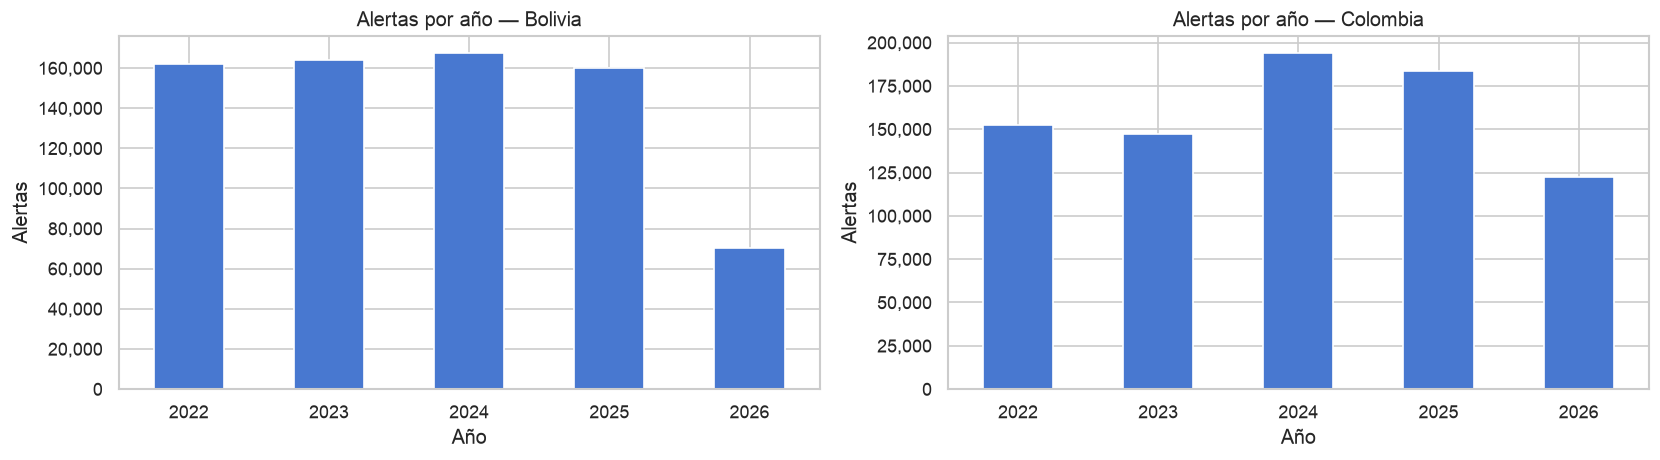

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (code, df) in zip(axes, frames.items()):
    df['gfw_integrated_alerts__date'].dt.year.value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(f'Alertas por año — {COUNTRIES[code]}')
    ax.set_xlabel('Año'); ax.set_ylabel('Alertas')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(RES / 'eda_gfw_alertas_por_anio.png', dpi=120)
plt.show()

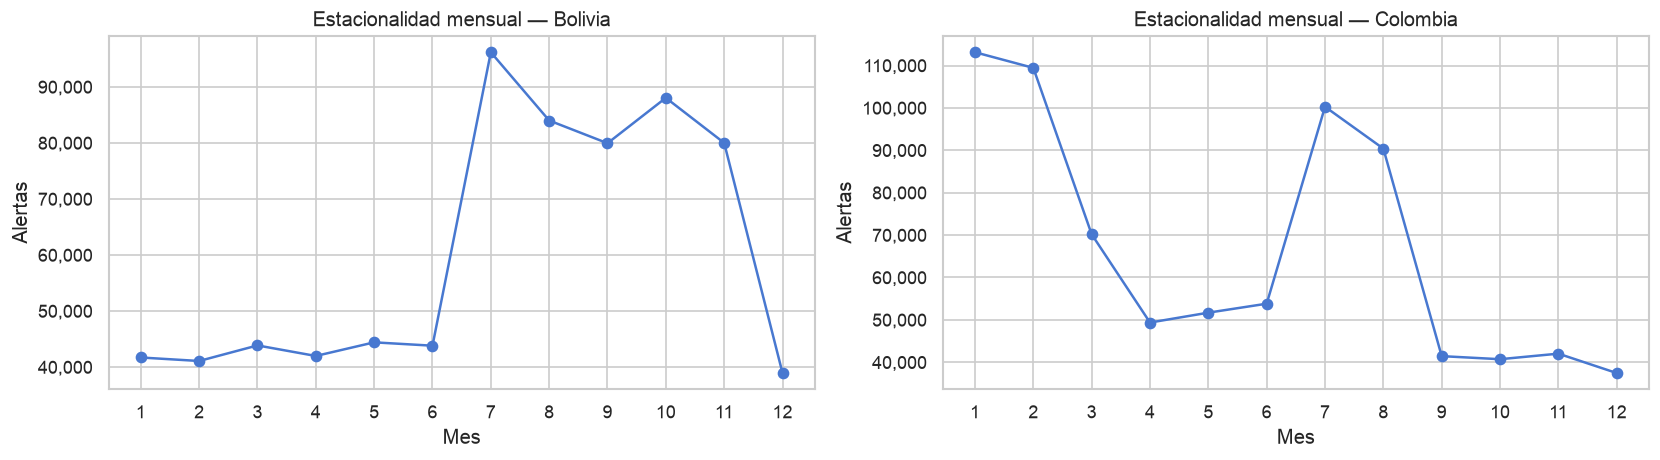

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (code, df) in zip(axes, frames.items()):
    df['gfw_integrated_alerts__date'].dt.month.value_counts().sort_index().plot(ax=ax, marker='o')
    ax.set_title(f'Estacionalidad mensual — {COUNTRIES[code]}')
    ax.set_xlabel('Mes'); ax.set_ylabel('Alertas')
    ax.set_xticks(range(1, 13))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(RES / 'eda_gfw_estacionalidad.png', dpi=120)
plt.show()

## 4b. Distribución de densidad de cobertura arbórea
Analiza el histograma de `tree_cover_density_pct` para entender qué porcentaje de cobertura arbórea tenían los píxeles deforestados en el año 2000.

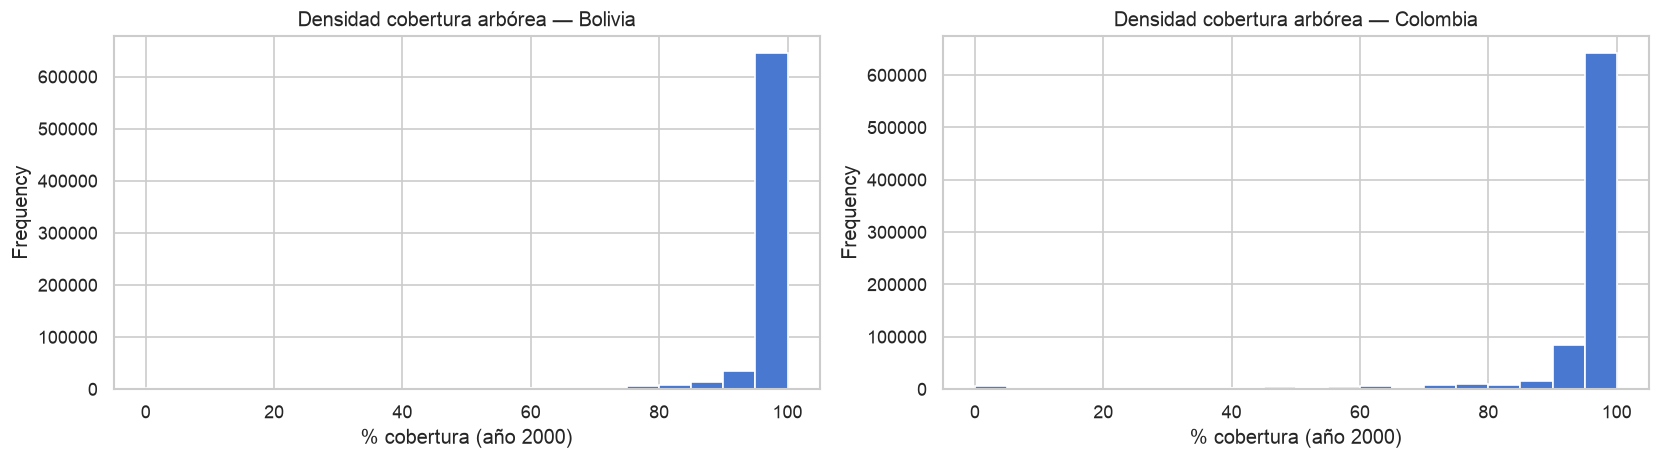

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (code, df) in zip(axes, frames.items()):
    col = 'umd_tree_cover_density_2000__percent'
    df[col].dropna().plot(kind='hist', bins=20, ax=ax)
    ax.set_title(f'Densidad cobertura arbórea — {COUNTRIES[code]}')
    ax.set_xlabel('% cobertura (año 2000)')
plt.tight_layout()
plt.savefig(RES / 'eda_gfw_densidad_cobertura.png', dpi=120)
plt.show()

## 4c. Hallazgos y decisiones de transformación
Tabla resumen que conecta cada hallazgo del EDA con la decisión de transformación correspondiente aplicada en `05_etl_pipeline.ipynb`.

| Hallazgo | Decisión |
|----------|----------|
| `land_cover_class` tiene nulos (BOL 0.02%, COL 3.38%) | Mantener nulos → FK nullable en `fact_alerts` |
| `adm1_code` tiene valores fuera del mapa (17, 18, 22, 9999 en BOL) | Mapear a `adm1_code = -1` / `adm1_name = 'Desconocido'` |
| `confidence` tiene 3 valores: nominal, high, highest | Derivar `is_high_confidence = 1` si high/highest |
| `loss_driver_category` usa código 255 para sin clasificar | Mapear explícitamente a 'Sin clasificar' |
| 0 duplicados en ambos países | No se requiere deduplicación |
| Columnas con nombres largos tipo `gfw_integrated_alerts__date` | Renombrar a nombres cortos en transformación |

## 5. Tasas de cambio temporal
Calcula la variación porcentual año a año de alertas por país, genera un heatmap de estacionalidad mes × año y una tendencia rolling de 3 meses para suavizar el ruido.

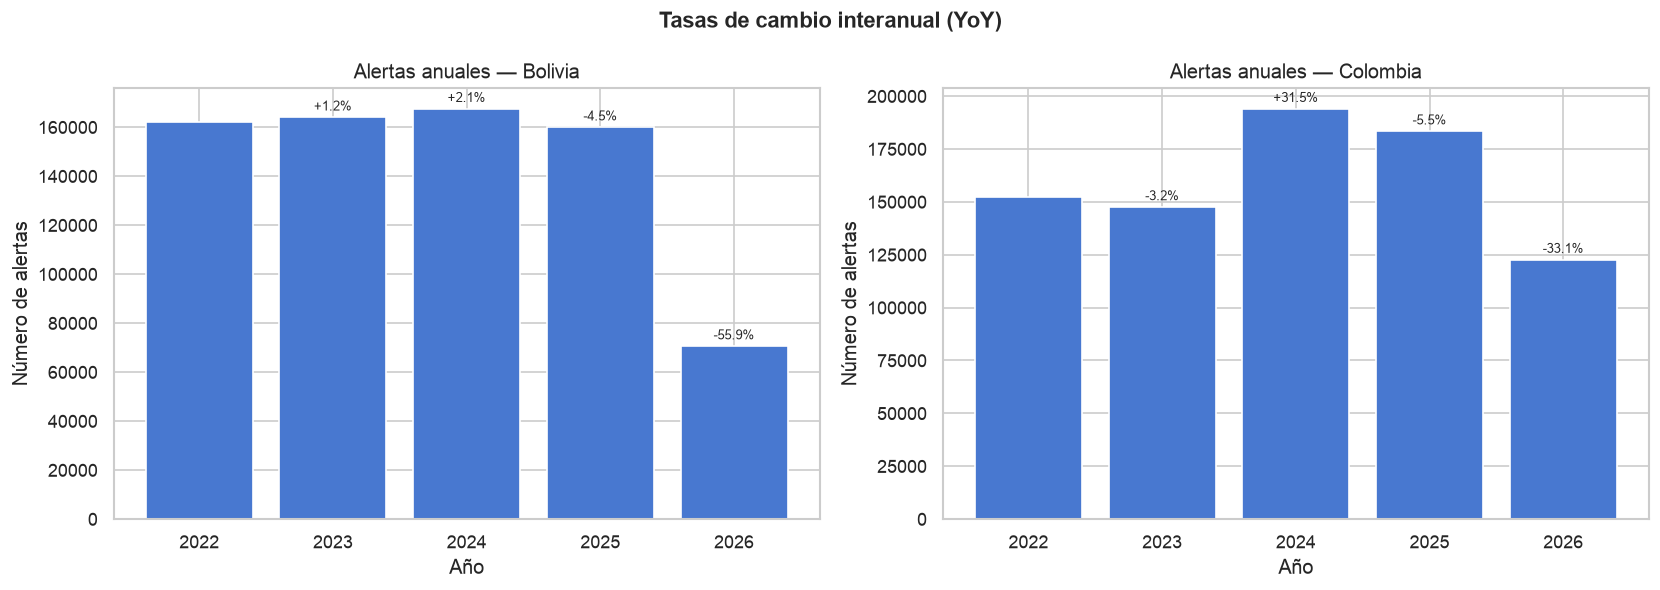

Guardado: eda_gfw_tasas_cambio.png


In [93]:
# Carga unificada de ambos países (reutiliza find_csv y la lógica de carga existente)
import warnings
warnings.filterwarnings('ignore')

dfs = {}
for code, name in COUNTRIES.items():
    df_raw = pd.read_csv(find_csv(code), low_memory=False)
    df_raw['alert_date'] = pd.to_datetime(df_raw['alert__date'] if 'alert__date' in df_raw.columns else df_raw['gfw_integrated_alerts__date'], errors='coerce')
    df_raw['year'] = df_raw['alert_date'].dt.year
    df_raw['month'] = df_raw['alert_date'].dt.month
    df_raw['country'] = name
    df_raw['country_code'] = code
    dfs[code] = df_raw
df_all = pd.concat(dfs.values(), ignore_index=True)

# 5.1 Alertas anuales con anotación % YoY
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (code, name) in zip(axes, COUNTRIES.items()):
    ann = (df_all[df_all['country_code'] == code]
           .groupby('year').size().reset_index(name='count'))
    ann['yoy'] = ann['count'].pct_change() * 100
    bars = ax.bar(ann['year'], ann['count'], color=sns.color_palette('muted')[0])
    for bar, row in zip(bars, ann.itertuples()):
        if not pd.isna(row.yoy):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + ann['count'].max() * 0.01,
                    f'{row.yoy:+.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Alertas anuales — {name}')
    ax.set_xlabel('Año'); ax.set_ylabel('Número de alertas')
fig.suptitle('Tasas de cambio interanual (YoY)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RES / 'eda_gfw_tasas_cambio.png', bbox_inches='tight')
plt.show()
print('Guardado: eda_gfw_tasas_cambio.png')

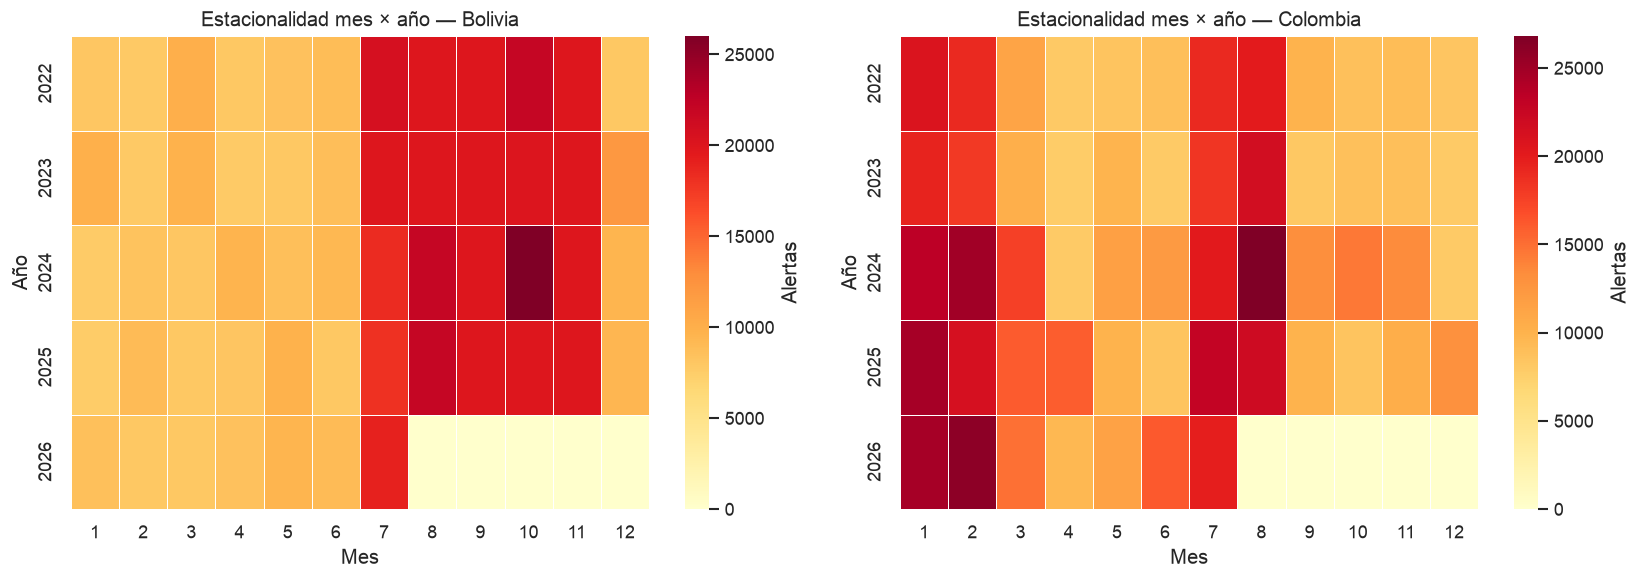

Guardado: eda_gfw_estacionalidad_anual.png


In [94]:
# 5.2 Heatmap estacionalidad mes × año por país
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (code, name) in zip(axes, COUNTRIES.items()):
    pivot = (df_all[df_all['country_code'] == code]
             .groupby(['year', 'month']).size().unstack(fill_value=0))
    pivot.columns = [str(c) for c in pivot.columns]
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.5,
                cbar_kws={'label': 'Alertas'})
    ax.set_title(f'Estacionalidad mes × año — {name}')
    ax.set_xlabel('Mes'); ax.set_ylabel('Año')
plt.tight_layout()
plt.savefig(RES / 'eda_gfw_estacionalidad_anual.png', bbox_inches='tight')
plt.show()
print('Guardado: eda_gfw_estacionalidad_anual.png')

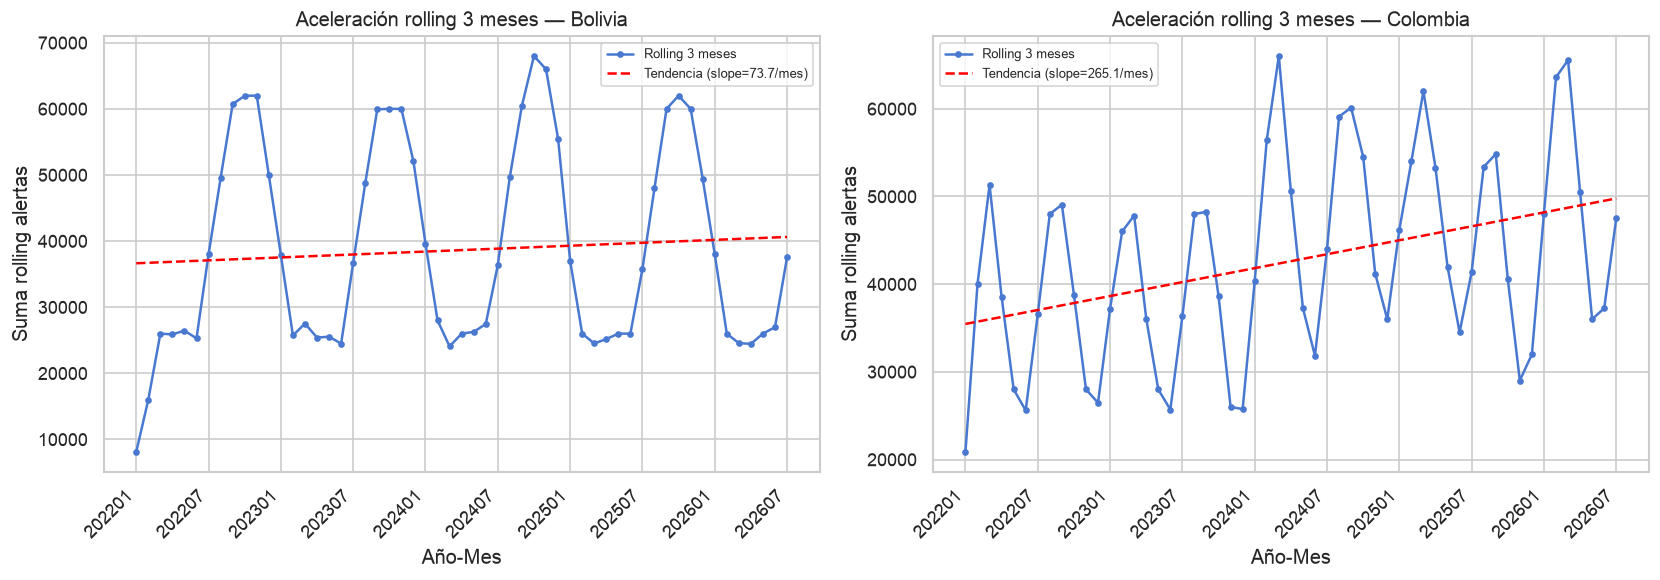

Guardado: eda_gfw_rolling_tendencia.png


In [95]:
# 5.3 Tendencia rolling 3 meses por país
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (code, name) in zip(axes, COUNTRIES.items()):
    monthly = (df_all[df_all['country_code'] == code]
               .groupby(['year', 'month']).size().reset_index(name='count'))
    monthly['period'] = monthly['year'] * 100 + monthly['month']
    monthly = monthly.sort_values('period')
    monthly['rolling3'] = monthly['count'].rolling(3, min_periods=1).sum()
    x = np.arange(len(monthly))
    m, b = np.polyfit(x, monthly['rolling3'], 1)
    ax.plot(monthly['period'].astype(str), monthly['rolling3'], marker='o', ms=3,
            label='Rolling 3 meses')
    ax.plot(monthly['period'].astype(str), m * x + b, '--', color='red', linewidth=1.5,
            label=f'Tendencia (slope={m:.1f}/mes)')
    step = max(1, len(monthly) // 8)
    ax.set_xticks(range(0, len(monthly), step))
    ax.set_xticklabels(monthly['period'].astype(str).iloc[::step], rotation=45, ha='right')
    ax.set_title(f'Aceleración rolling 3 meses — {name}')
    ax.set_xlabel('Año-Mes'); ax.set_ylabel('Suma rolling alertas')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RES / 'eda_gfw_rolling_tendencia.png', bbox_inches='tight')
plt.show()
print('Guardado: eda_gfw_rolling_tendencia.png')

## 6. Identificación de patrones espaciales
Identifica los departamentos con más alertas, visualiza la densidad geográfica con hexbin y analiza el mix de drivers en los top-5 departamentos más afectados.

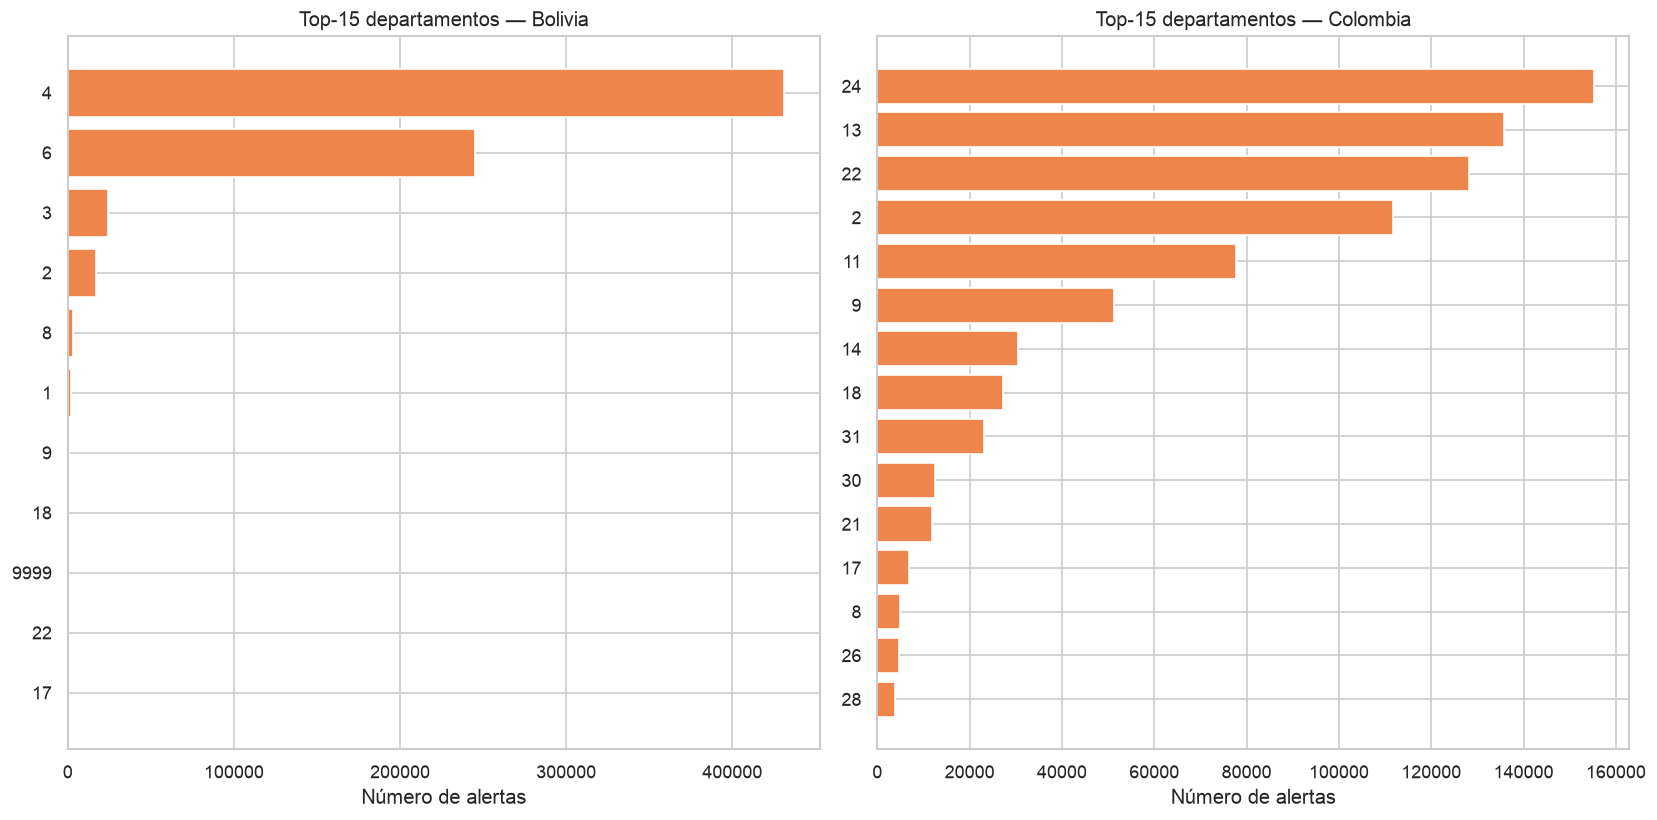

Guardado: eda_gfw_hotspots.png


In [96]:
# 6.1 Top-N departamentos (adm1) por alertas
ADM1_COL = next((c for c in df_all.columns if 'adm1' in c.lower()), None)
if ADM1_COL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    for ax, (code, name) in zip(axes, COUNTRIES.items()):
        top = (df_all[df_all['country_code'] == code]
               .groupby(ADM1_COL).size().nlargest(15)
               .reset_index(name='count'))
        ax.barh(top[ADM1_COL].astype(str), top['count'],
                color=sns.color_palette('muted')[1])
        ax.invert_yaxis()
        ax.set_title(f'Top-15 departamentos — {name}')
        ax.set_xlabel('Número de alertas')
    plt.tight_layout()
    plt.savefig(RES / 'eda_gfw_hotspots.png', bbox_inches='tight')
    plt.show()
    print('Guardado: eda_gfw_hotspots.png')
else:
    print('⚠️ Columna adm1 no encontrada, omitiendo sección 6.1')

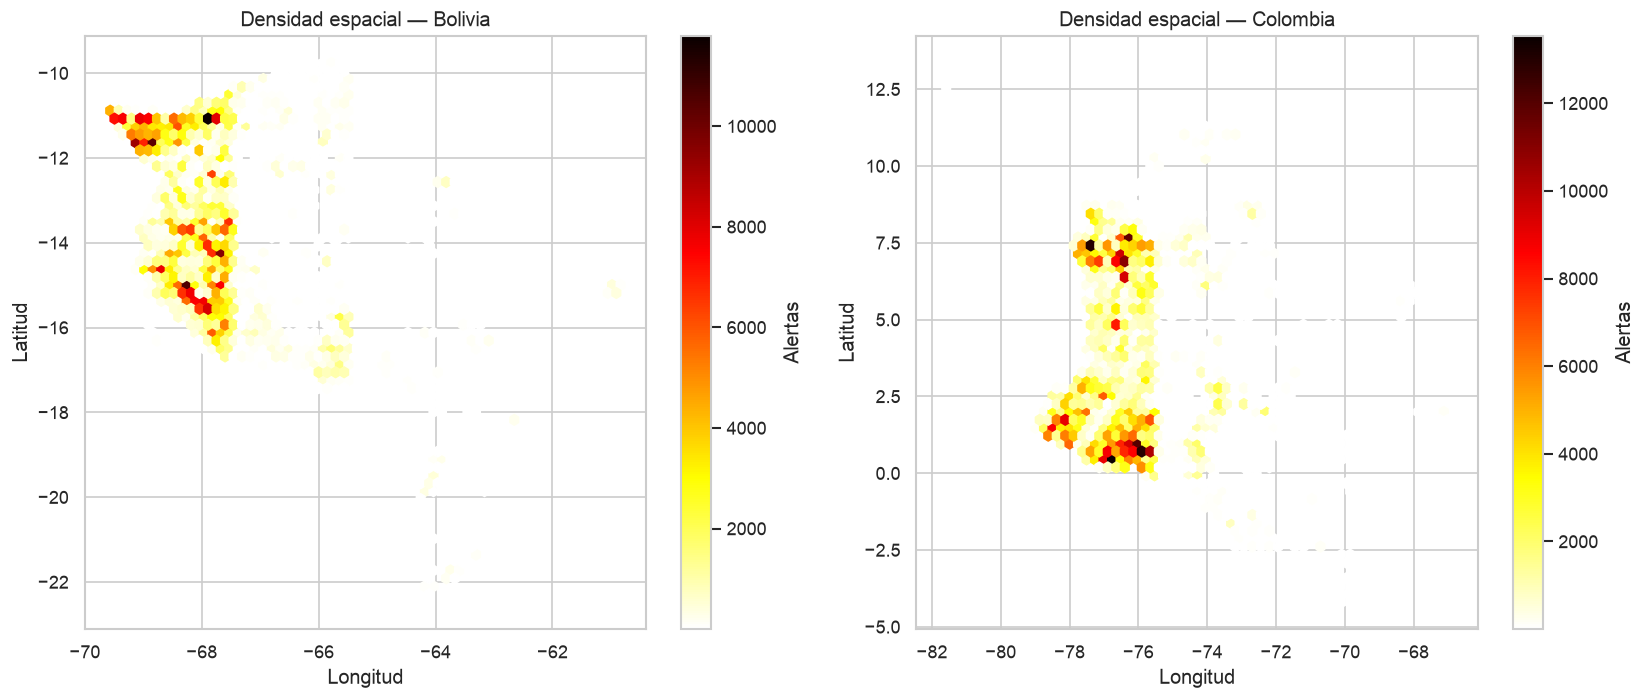

Guardado: eda_gfw_densidad_espacial.png


In [97]:
# 6.2 Mapa densidad lat/lon (hexbin)
LAT_COL = next((c for c in df_all.columns if c.lower() in ('latitude', 'lat', 'alert__lat')), None)
LON_COL = next((c for c in df_all.columns if c.lower() in ('longitude', 'lon', 'alert__lon')), None)
if LAT_COL and LON_COL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, (code, name) in zip(axes, COUNTRIES.items()):
        sub = df_all[df_all['country_code'] == code][[LAT_COL, LON_COL]].dropna()
        hb = ax.hexbin(sub[LON_COL], sub[LAT_COL], gridsize=60, cmap='hot_r', mincnt=1)
        plt.colorbar(hb, ax=ax, label='Alertas')
        ax.set_title(f'Densidad espacial — {name}')
        ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
    plt.tight_layout()
    plt.savefig(RES / 'eda_gfw_densidad_espacial.png', bbox_inches='tight')
    plt.show()
    print('Guardado: eda_gfw_densidad_espacial.png')
else:
    print('⚠️ Columnas lat/lon no encontradas, omitiendo sección 6.2')

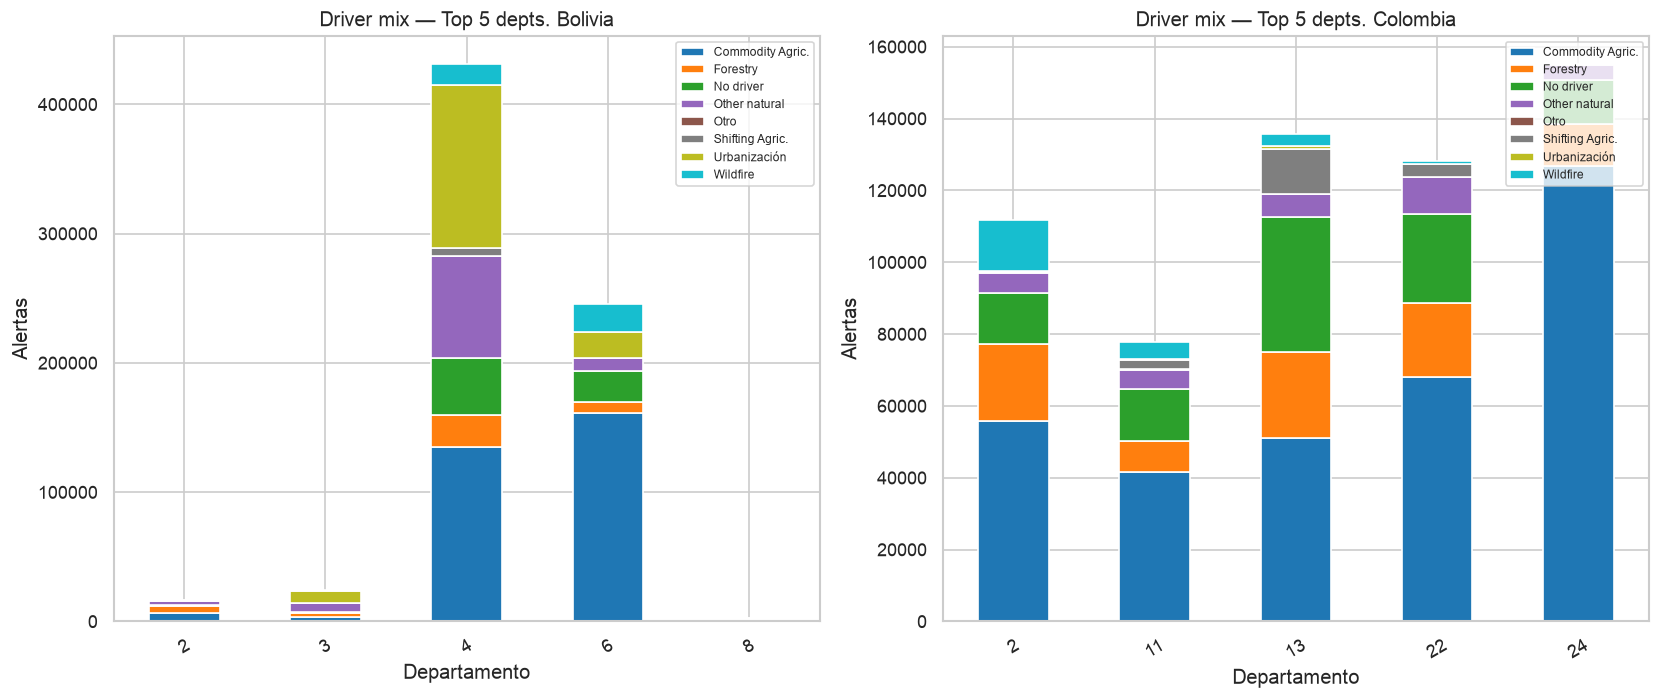

Guardado: eda_gfw_driver_mix.png


In [98]:
# 6.3 Driver mix en top-5 departamentos
DRIVER_COL = next((c for c in df_all.columns if 'driver' in c.lower()), None)
DRIVER_MAP = {1: 'Commodity Agric.', 2: 'Shifting Agric.', 3: 'Forestry',
              4: 'Wildfire', 5: 'Urbanización', 7: 'Other natural', 255: 'No driver'}
if ADM1_COL and DRIVER_COL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, (code, name) in zip(axes, COUNTRIES.items()):
        sub = df_all[df_all['country_code'] == code]
        top5 = sub.groupby(ADM1_COL).size().nlargest(5).index
        sub5 = sub[sub[ADM1_COL].isin(top5)].copy()
        sub5['driver_name'] = sub5[DRIVER_COL].map(DRIVER_MAP).fillna('Otro')
        pivot = sub5.groupby([ADM1_COL, 'driver_name']).size().unstack(fill_value=0)
        pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
        ax.set_title(f'Driver mix — Top 5 depts. {name}')
        ax.set_xlabel('Departamento'); ax.set_ylabel('Alertas')
        ax.tick_params(axis='x', rotation=30)
        ax.legend(fontsize=7, loc='upper right')
    plt.tight_layout()
    plt.savefig(RES / 'eda_gfw_driver_mix.png', bbox_inches='tight')
    plt.show()
    print('Guardado: eda_gfw_driver_mix.png')
else:
    print('⚠️ Columnas adm1 o driver no encontradas, omitiendo sección 6.3')

## 7. Causalidad preliminar — alertas vs. indicadores económicos
Cruza las alertas anuales con indicadores del World Bank (tierra agrícola, PIB) usando correlación de Pearson para identificar relaciones entre presión económica y deforestación.

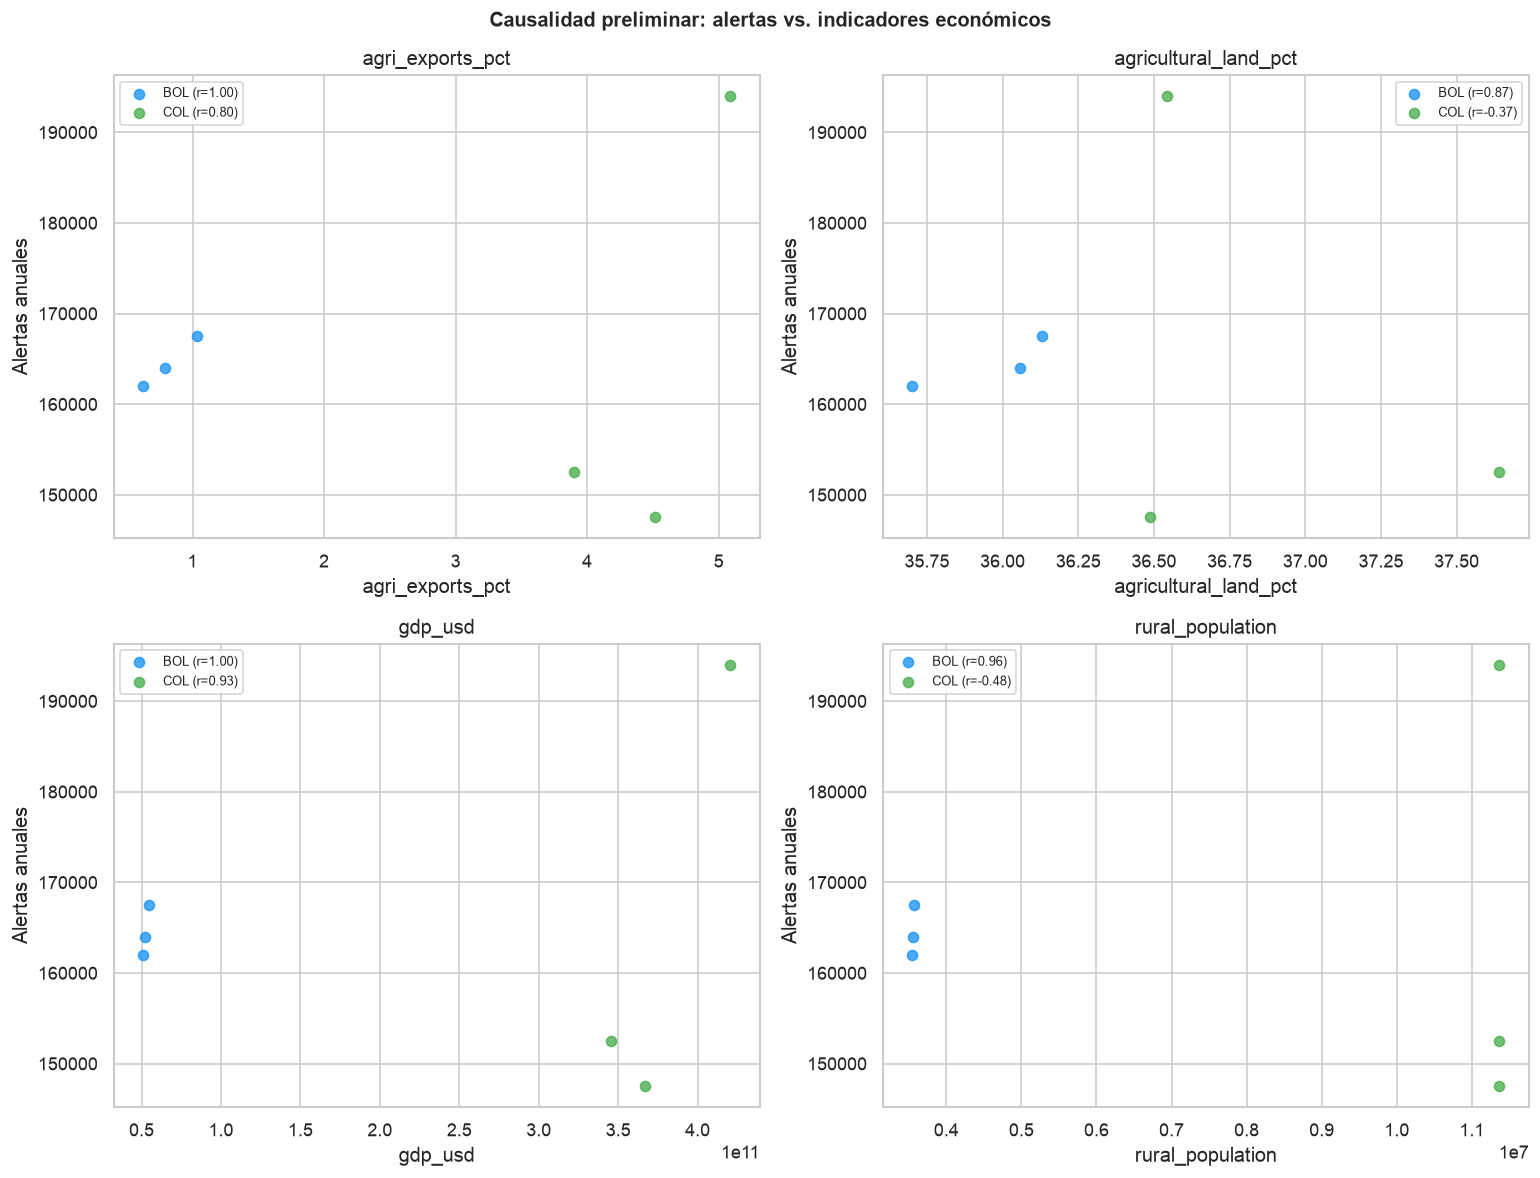

Guardado: eda_gfw_causalidad.png


In [99]:
# 7. Correlación alertas anuales vs. indicadores World Bank
import scipy.stats as stats
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RES = Path('../data/results')
RES.mkdir(parents=True, exist_ok=True)

wb_path = Path('../data/external/worldbank/worldbank_indicators.csv')
if wb_path.exists():
    wb = pd.read_csv(wb_path)
    annual_alerts = (df_all.groupby(['country_code', 'year']).size()
                     .reset_index(name='alert_count'))
    # Normalizar / pivotear nombre de columnas worldbank si vienen en formato largo
    if 'indicator_name' in wb.columns and 'value' in wb.columns:
        wb = wb.pivot_table(index=['country_code', 'year'],
                            columns='indicator_name', values='value').reset_index()

    wb_cols = {c.lower(): c for c in wb.columns}
    id_col = next((v for k, v in wb_cols.items() if 'country' in k and 'code' in k), 'country_code')
    year_col = next((v for k, v in wb_cols.items() if 'year' in k), 'year')
    indicators = [c for c in wb.columns if c not in [id_col, year_col] and np.issubdtype(wb[c].dtype, np.number)]
    if id_col and year_col and indicators:
        wb_pivot = wb.rename(columns={id_col: 'country_code', year_col: 'year'})
        merged = annual_alerts.merge(wb_pivot, on=['country_code', 'year'], how='inner')
        n_ind = min(4, len(indicators))
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))
        axes = axes.flatten()
        palette = {'BOL': '#2196F3', 'COL': '#4CAF50'}
        for i, ind in enumerate(indicators[:n_ind]):
            ax = axes[i]
            for code in ['BOL', 'COL']:
                sub = merged[merged['country_code'] == code].dropna(subset=[ind, 'alert_count'])
                x_vals = pd.to_numeric(sub[ind], errors='coerce')
                y_vals = pd.to_numeric(sub['alert_count'], errors='coerce')
                valid = x_vals.notna() & y_vals.notna()
                if valid.sum() >= 3 and x_vals[valid].std() > 0 and y_vals[valid].std() > 0:
                    r, _ = stats.pearsonr(x_vals[valid], y_vals[valid])
                    ax.scatter(x_vals[valid], y_vals[valid], label=f'{code} (r={r:.2f})',
                               color=palette.get(code, 'gray'), alpha=0.8)
                elif valid.sum() > 0:
                    ax.scatter(x_vals[valid], y_vals[valid], label=f'{code}',
                               color=palette.get(code, 'gray'), alpha=0.8)
            ax.set_xlabel(ind); ax.set_ylabel('Alertas anuales')
            ax.set_title(ind)
            ax.legend(fontsize=8)
        for j in range(n_ind, 4):
            axes[j].set_visible(False)
        fig.suptitle('Causalidad preliminar: alertas vs. indicadores económicos',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(RES / 'eda_gfw_causalidad.png', bbox_inches='tight')
        plt.show()
        print('Guardado: eda_gfw_causalidad.png')
else:
    print('⚠️ worldbank_indicators.csv no encontrado — ejecutar 02_eda_worldbank.ipynb primero')


## 8. Proximidad a centros poblados
Calcula la distancia mínima de una muestra de alertas al centro poblado más cercano (GeoNames) usando KD-Tree. Analiza si las alertas ocurren cerca o lejos de asentamientos humanos.

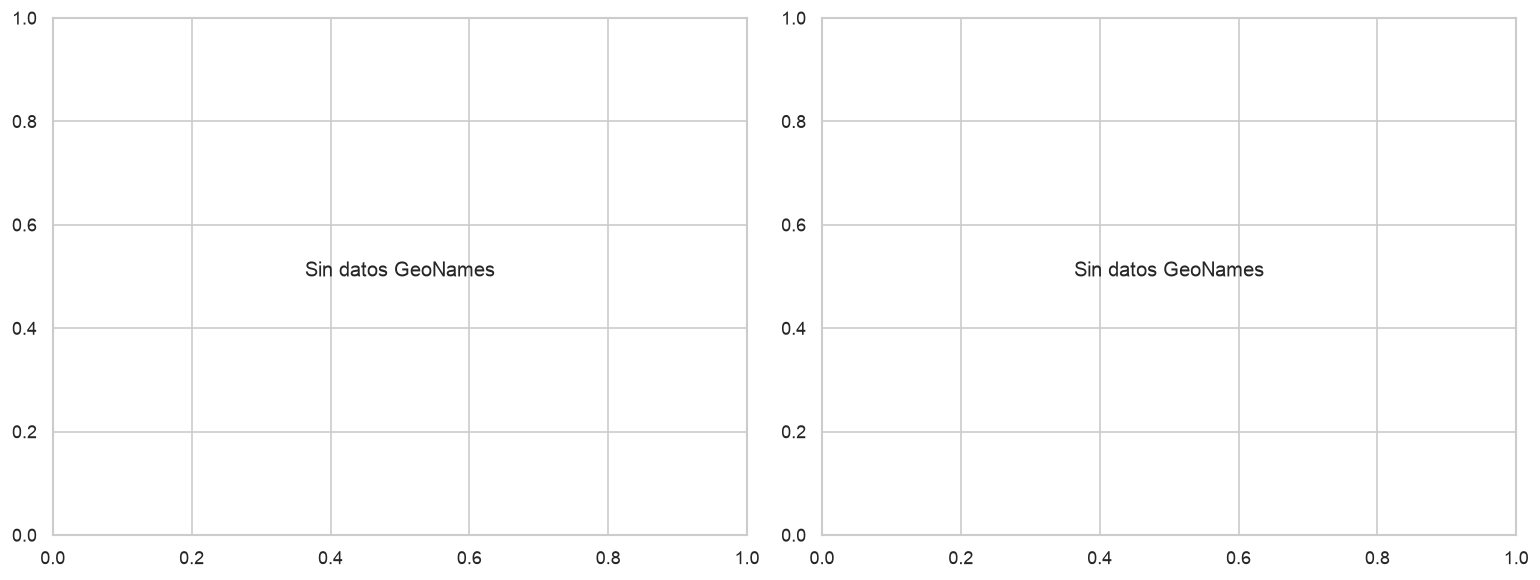

Guardado: eda_gfw_distancia_poblados.png


In [100]:
# 8. Distancia de alertas a centros poblados (GeoNames)
from scipy.spatial import cKDTree
from IPython.display import display

geo_paths = [
    Path('../data/external/geonames/geonames_places.csv'),
    Path('data/external/geonames/geonames_places.csv')
]
geo_path = next((p for p in geo_paths if p.exists()), None)

LAT_COL = next((c for c in df_all.columns if c.lower() in ('latitude', 'lat', 'alert__lat')), None)
LON_COL = next((c for c in df_all.columns if c.lower() in ('longitude', 'lon', 'alert__lon')), None)

if LAT_COL and LON_COL and geo_path:
    geo = pd.read_csv(geo_path)
    geo_lat = next((c for c in geo.columns if 'lat' in c.lower()), None)
    geo_lon = next((c for c in geo.columns if 'lon' in c.lower()), None)
    
    if geo_lat and geo_lon:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        iso2_map = {'BOL': 'BO', 'COL': 'CO'}
        
        for ax, (code, name) in zip(axes, COUNTRIES.items()):
            # Filtrar geonames por país (compatible con ISO-3 'BOL'/'COL' e ISO-2 'BO'/'CO')
            iso2 = iso2_map.get(code, code[:2])
            mask = pd.Series(False, index=geo.index)
            if 'country_iso3' in geo.columns:
                mask |= (geo['country_iso3'] == code)
            if 'country_code' in geo.columns:
                mask |= (geo['country_code'] == code) | (geo['country_code'] == iso2)
            
            geo_sub = geo[mask][[geo_lat, geo_lon]].dropna() if mask.any() else geo[[geo_lat, geo_lon]].dropna()
            if len(geo_sub) == 0:
                ax.text(0.5, 0.5, 'Sin datos GeoNames', transform=ax.transAxes, ha='center')
                continue
            
            tree = cKDTree(geo_sub[[geo_lat, geo_lon]].values)
            # Muestra de alertas del país
            country_alerts = df_all[df_all['country_code'] == code][[LAT_COL, LON_COL]].dropna()
            sample_size = min(10000, len(country_alerts))
            if sample_size == 0:
                ax.text(0.5, 0.5, f'Sin alertas para {name}', transform=ax.transAxes, ha='center')
                continue
                
            alerts_sub = country_alerts.sample(sample_size, random_state=42)
            dists, _ = tree.query(alerts_sub[[LAT_COL, LON_COL]].values)
            dists_km = dists * 111  # grados a km aproximados
            ax.hist(dists_km, bins=50, color=sns.color_palette('muted')[2], edgecolor='white')
            ax.axvline(dists_km.mean(), color='red', linestyle='--',
                       label=f'Media: {dists_km.mean():.1f} km')
            ax.axvline(np.median(dists_km), color='orange', linestyle='-.',
                       label=f'Mediana: {np.median(dists_km):.1f} km')
            ax.set_title(f'Distancia a centro poblado más cercano — {name}')
            ax.set_xlabel('Distancia (km)'); ax.set_ylabel('Frecuencia')
            ax.legend(fontsize=8)
            
        plt.tight_layout()
        plt.savefig(RES / 'eda_gfw_distancia_poblados.png', bbox_inches='tight')
        display(fig)
        plt.show()
        print('Guardado: eda_gfw_distancia_poblados.png')
else:
    print('⚠️ geonames_places.csv o columnas lat/lon no disponibles — omitiendo sección 8')